import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px


In [1]:
import sys
print(sys.executable)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px



c:\Users\ashu1\Desktop\NumericPatternAssessment\venv\Scripts\python.exe


In [2]:
import warnings
warnings.filterwarnings("ignore")

import os
import time
import joblib

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 20)

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [3]:
df = pd.read_csv("../data/numeric_pattern.csv")

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


In [4]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

df.shape

Rows : 10050
Columns : 11


(10050, 11)

In [5]:
df.head()

,Feature_1_Age,Feature_2_Income,Feature_3_Experience,Feature_4_Education,Feature_5_Skill,Feature_6_Performance,Feature_7_Projects,Feature_8_Attendance,Feature_9_TrainingHours,Feature_10_IQ,Target
0,60.0,250533.570765,40.0,51.0,87.0,67.0,8.0,74.0,45.0,NaN,38012.809185
1,54.0,223288.442691,34.0,87.0,67.0,52.0,1.0,65.0,65.0,109.0,33979.169389
2,52.0,196879.233126,28.0,51.0,75.0,62.0,18.0,86.0,66.0,137.0,29926.071273
3,57.0,235896.064078,35.0,50.0,88.0,60.0,14.0,81.0,81.0,99.0,35906.153085
4,33.0,127252.628070,11.0,56.0,45.0,74.0,4.0,82.0,98.0,113.0,19414.350215


In [6]:
df.tail


<bound method NDFrame.tail of        Feature_1_Age  Feature_2_Income  Feature_3_Experience  \
0               60.0     250533.570765                  40.0   
1               54.0     223288.442691                  34.0   
2               52.0     196879.233126                  28.0   
3               57.0     235896.064078                  35.0   
4               33.0     127252.628070                  11.0   
...              ...               ...                   ...   
10045           28.0     119808.803883                   3.0   
10046           36.0     158294.574688                  16.0   
10047           52.0     179438.230387                  28.0   
10048           49.0     191863.724037                  24.0   
10049           52.0     200431.767775                   NaN   

       Feature_4_Education  Feature_5_Skill  Feature_6_Performance  \
0                     51.0             87.0                   67.0   
1                     87.0             67.0                  

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Feature_1_Age,9850.0,39.983452,11.858861,20.000000,30.000000,40.000000,50.000000,6.000000e+01
Feature_2_Income,9850.0,174065.057495,67047.291486,72113.448851,134297.356097,170568.676325,206316.380337,1.233181e+06
Feature_3_Experience,9848.0,17.668664,11.735326,0.000000,7.000000,17.000000,28.000000,4.000000e+01
Feature_4_Education,9850.0,75.062335,14.738592,50.000000,62.000000,75.000000,88.000000,1.000000e+02
Feature_5_Skill,9849.0,69.872880,17.738358,40.000000,54.000000,70.000000,85.000000,1.000000e+02
Feature_6_Performance,9850.0,75.079188,14.820050,50.000000,62.000000,75.000000,88.000000,1.000000e+02
Feature_7_Projects,9850.0,10.610254,5.776604,1.000000,6.000000,11.000000,16.000000,2.000000e+01
Feature_8_Attendance,9849.0,80.096456,11.828831,60.000000,70.000000,80.000000,90.000000,1.000000e+02
Feature_9_TrainingHours,9850.0,107.291269,55.226043,10.000000,59.000000,110.000000,155.000000,2.000000e+02
Feature_10_IQ,9847.0,114.990860,20.473709,80.000000,97.000000,115.000000,133.000000,1.500000e+02


In [8]:
df.isnull().sum()

Feature_1_Age              200
Feature_2_Income           200
Feature_3_Experience       202
Feature_4_Education        200
Feature_5_Skill            201
Feature_6_Performance      200
Feature_7_Projects         200
Feature_8_Attendance       201
Feature_9_TrainingHours    200
Feature_10_IQ              203
Target                     200
dtype: int64

In [9]:
(df.isnull().sum()/len(df))*100

Feature_1_Age              1.99005
Feature_2_Income           1.99005
Feature_3_Experience       2.00995
Feature_4_Education        1.99005
Feature_5_Skill            2.00000
Feature_6_Performance      1.99005
Feature_7_Projects         1.99005
Feature_8_Attendance       2.00000
Feature_9_TrainingHours    1.99005
Feature_10_IQ              2.01990
Target                     1.99005
dtype: float64

In [10]:
df.duplicated().sum()

np.int64(50)

In [11]:
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 50


In [12]:
df.fillna(df.median(numeric_only=True), inplace=True)

print("Missing Values After Cleaning")
print(df.isnull().sum())

Missing Values After Cleaning
Feature_1_Age              0
Feature_2_Income           0
Feature_3_Experience       0
Feature_4_Education        0
Feature_5_Skill            0
Feature_6_Performance      0
Feature_7_Projects         0
Feature_8_Attendance       0
Feature_9_TrainingHours    0
Feature_10_IQ              0
Target                     0
dtype: int64


In [13]:
before = df.shape[0]

df.drop_duplicates(inplace=True)

after = df.shape[0]

print("Rows Before :", before)
print("Rows After  :", after)
print("Duplicates Removed :", before-after)

Rows Before : 10050
Rows After  : 10000
Duplicates Removed : 50


In [14]:
for col in df.columns:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = ((df[col] < lower) | (df[col] > upper)).sum()

    print(f"{col} : {outliers}")

Feature_1_Age : 0
Feature_2_Income : 50
Feature_3_Experience : 0
Feature_4_Education : 0
Feature_5_Skill : 0
Feature_6_Performance : 0
Feature_7_Projects : 0
Feature_8_Attendance : 0
Feature_9_TrainingHours : 0
Feature_10_IQ : 0
Target : 0


In [15]:
for col in df.columns:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = np.where(df[col] < lower, lower, df[col])
    df[col] = np.where(df[col] > upper, upper, df[col])

print("Outliers Treated Successfully")

Outliers Treated Successfully


TASK 2

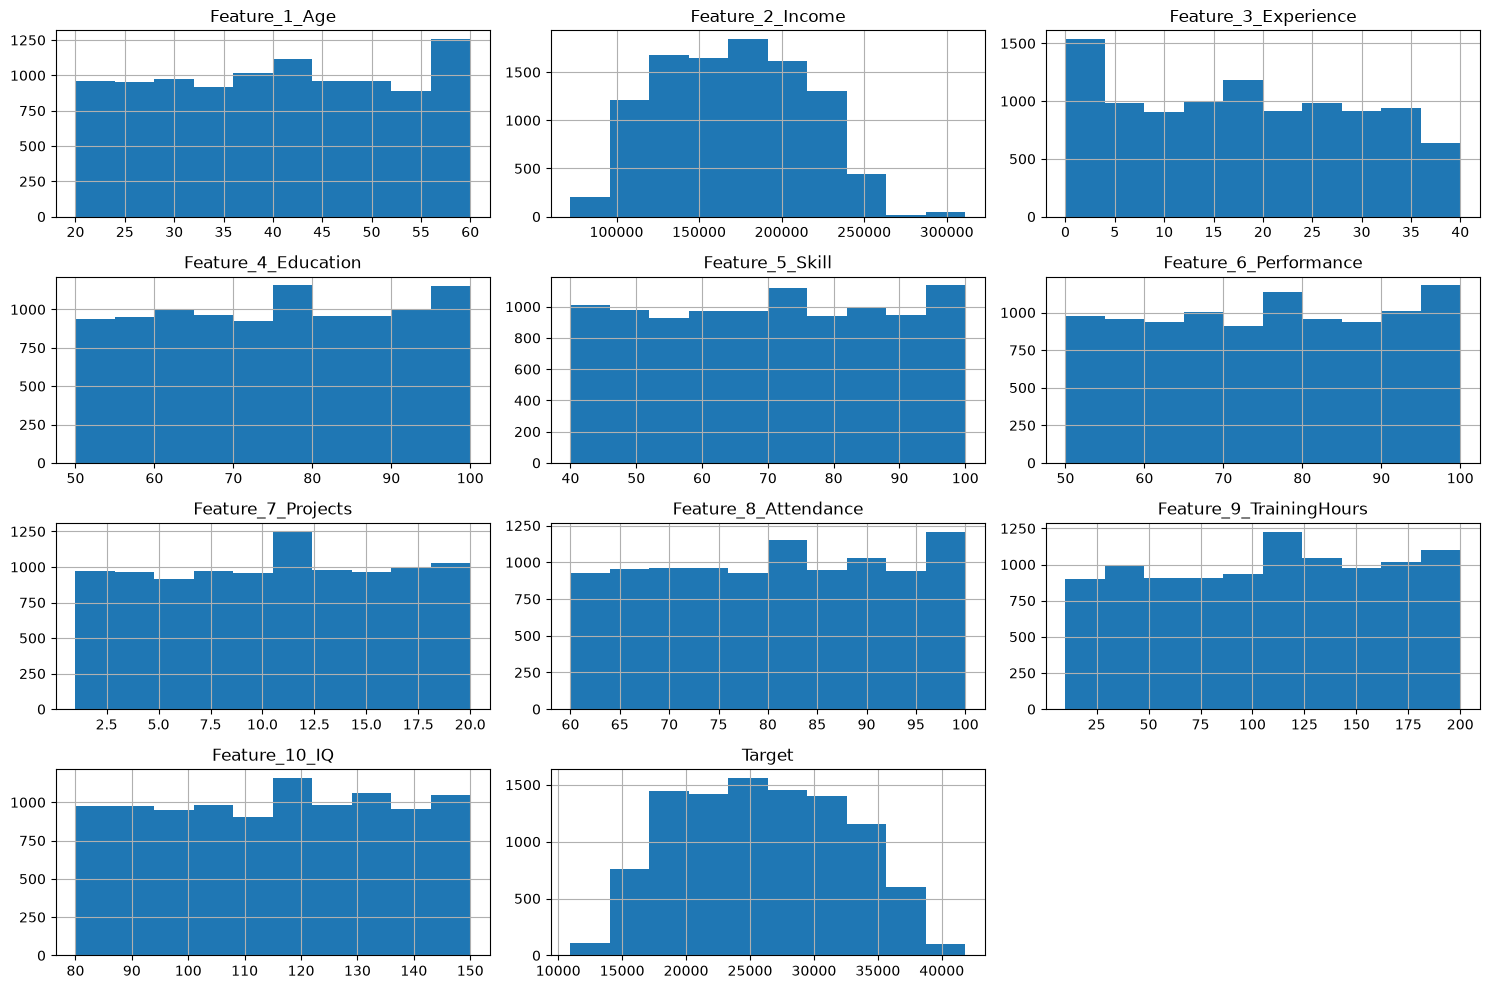

In [16]:
df.hist(figsize=(15,10))

plt.tight_layout()

plt.show()

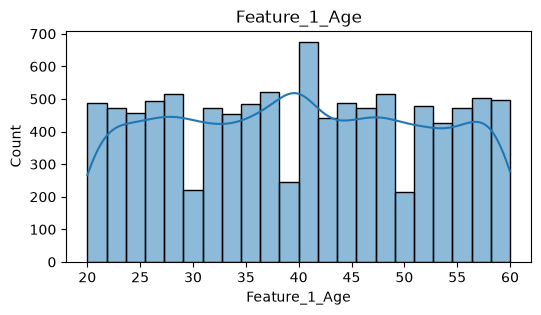

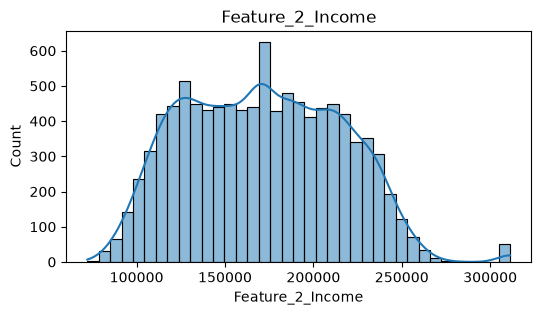

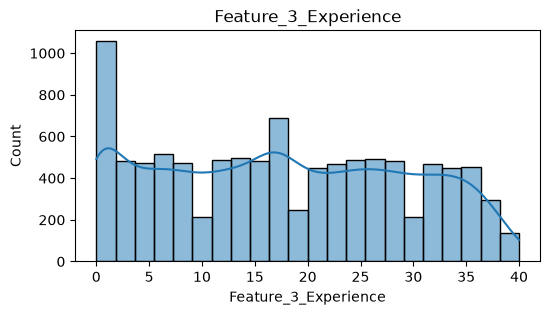

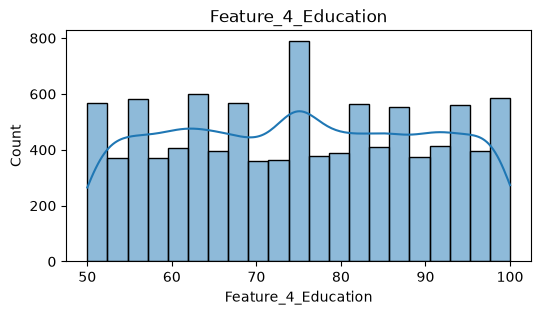

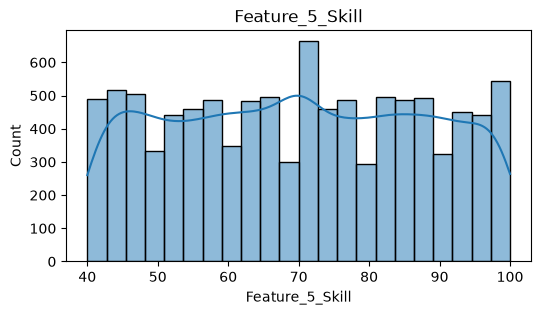

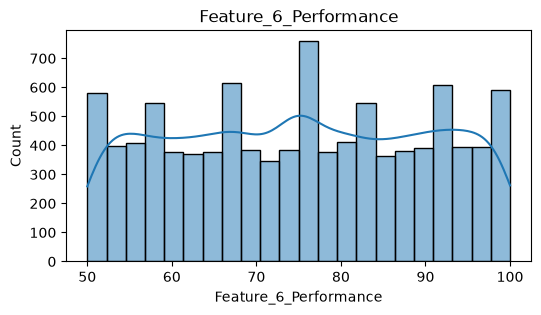

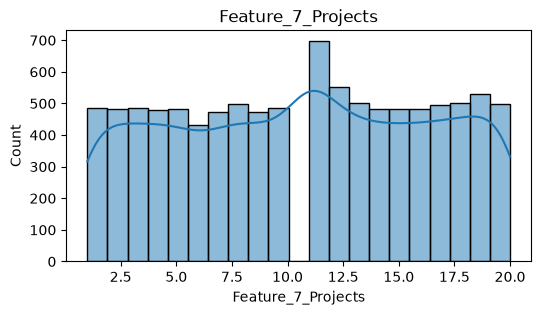

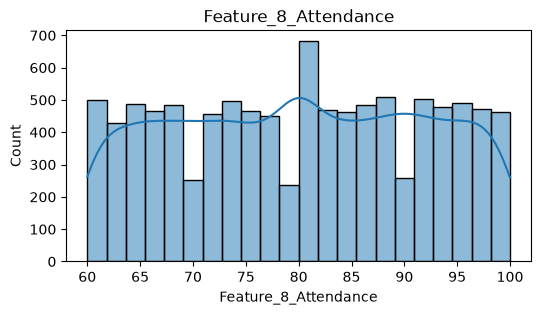

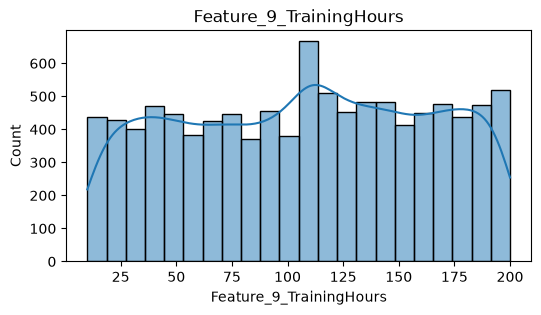

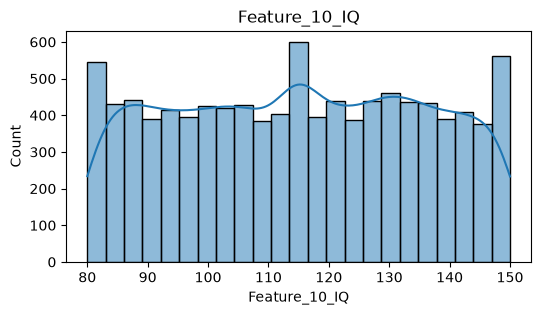

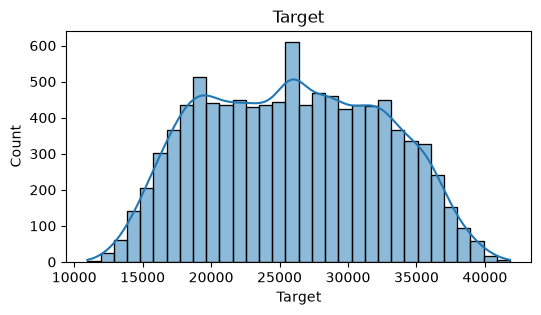

In [17]:
for col in df.columns:

    plt.figure(figsize=(6,3))

    sns.histplot(df[col], kde=True)

    plt.title(col)

    plt.show()

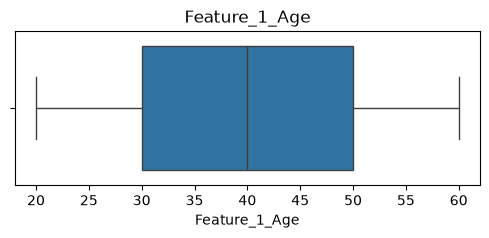

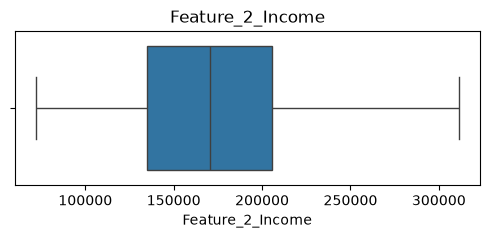

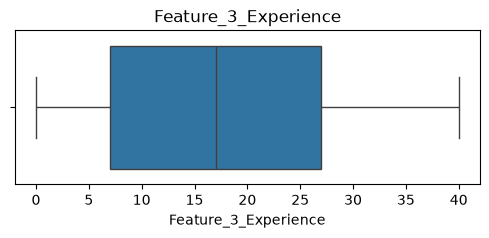

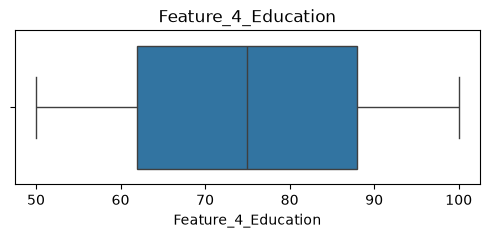

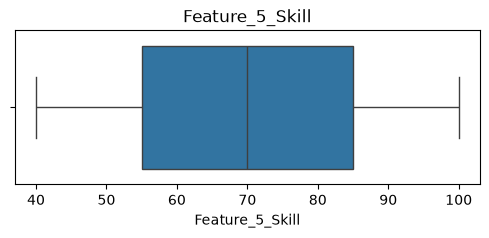

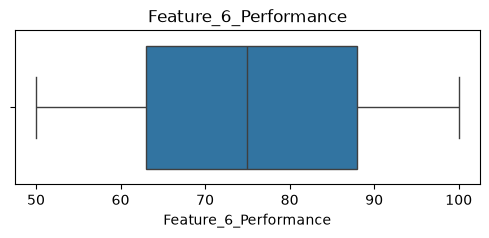

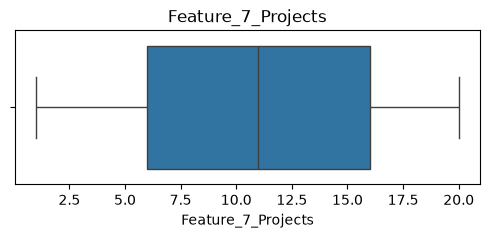

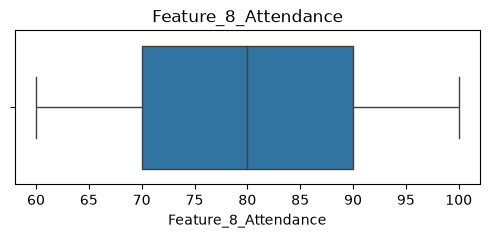

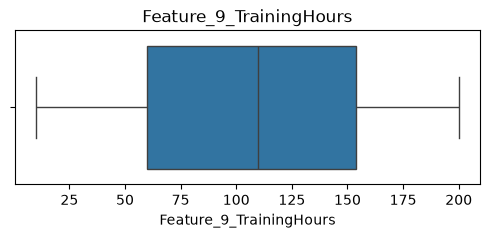

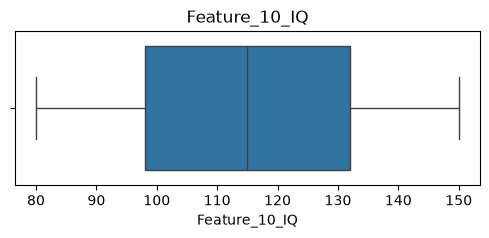

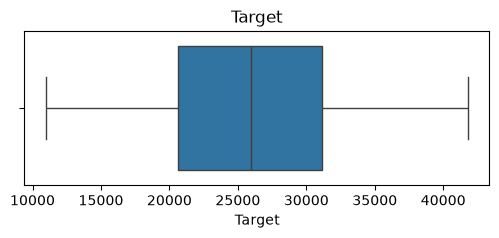

In [18]:
for col in df.columns:

    plt.figure(figsize=(6,2))

    sns.boxplot(x=df[col])

    plt.title(col)

    plt.show()

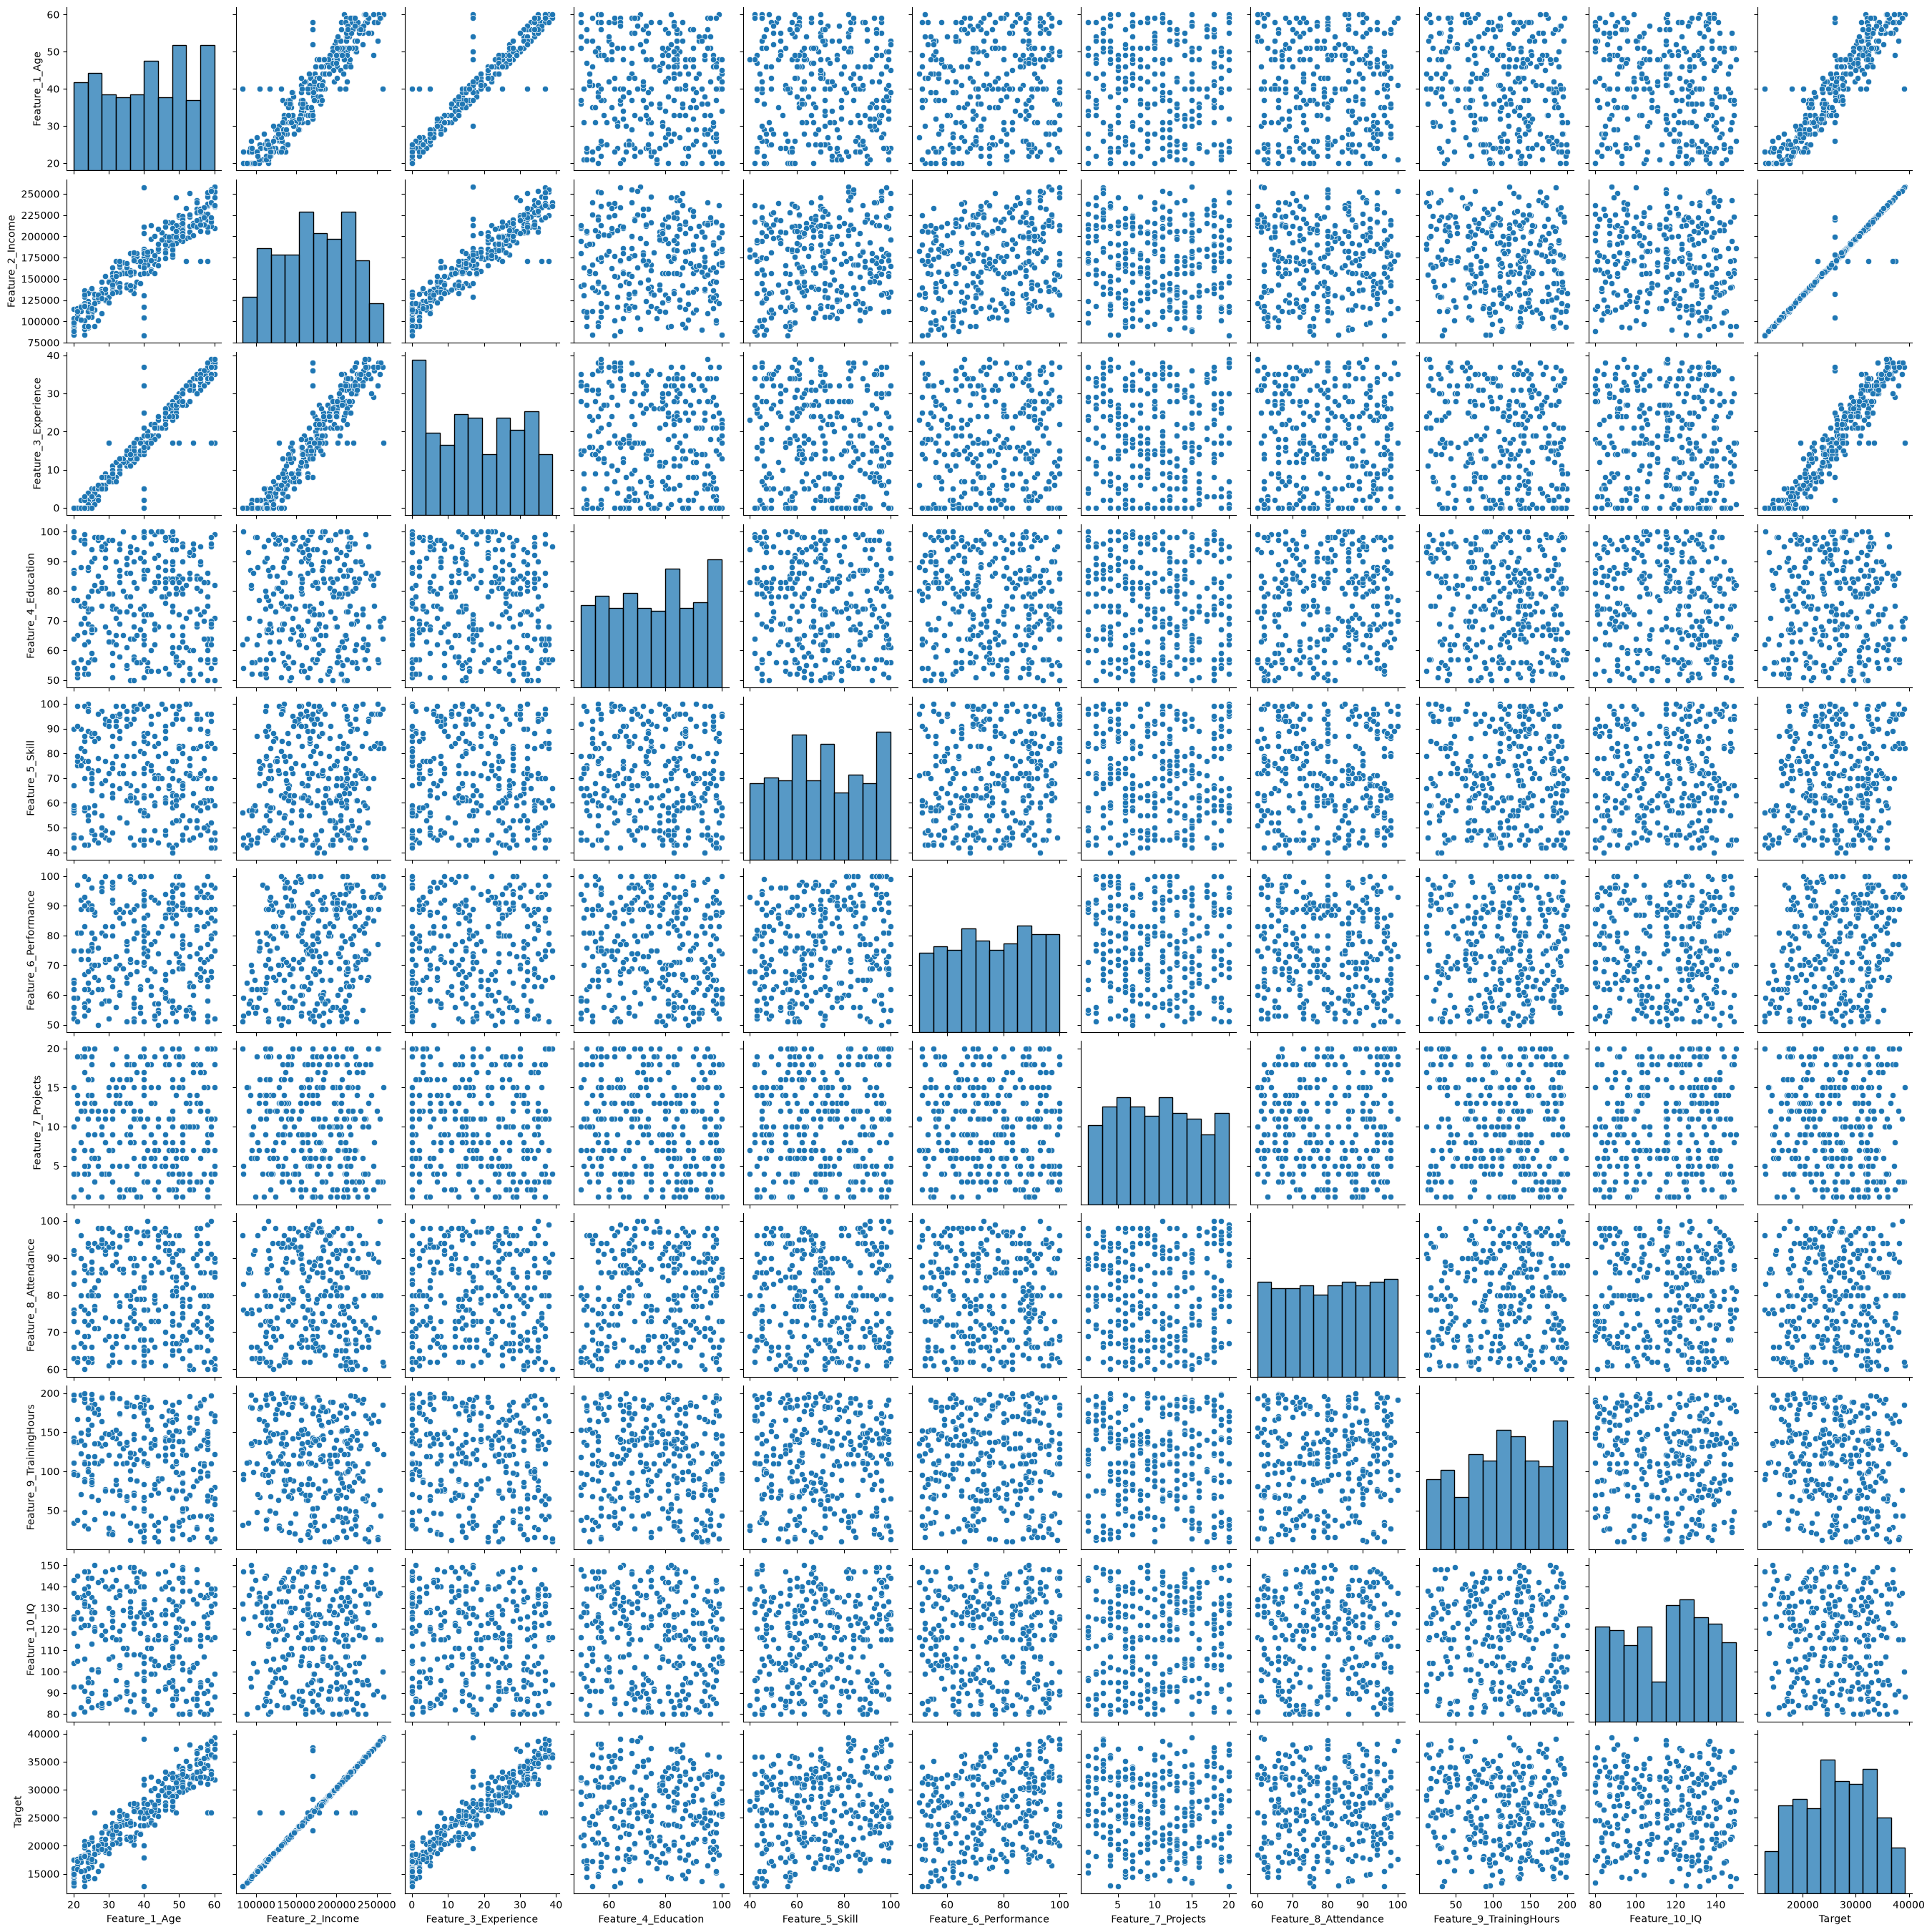

In [19]:
sns.pairplot(df.sample(300))

plt.show()

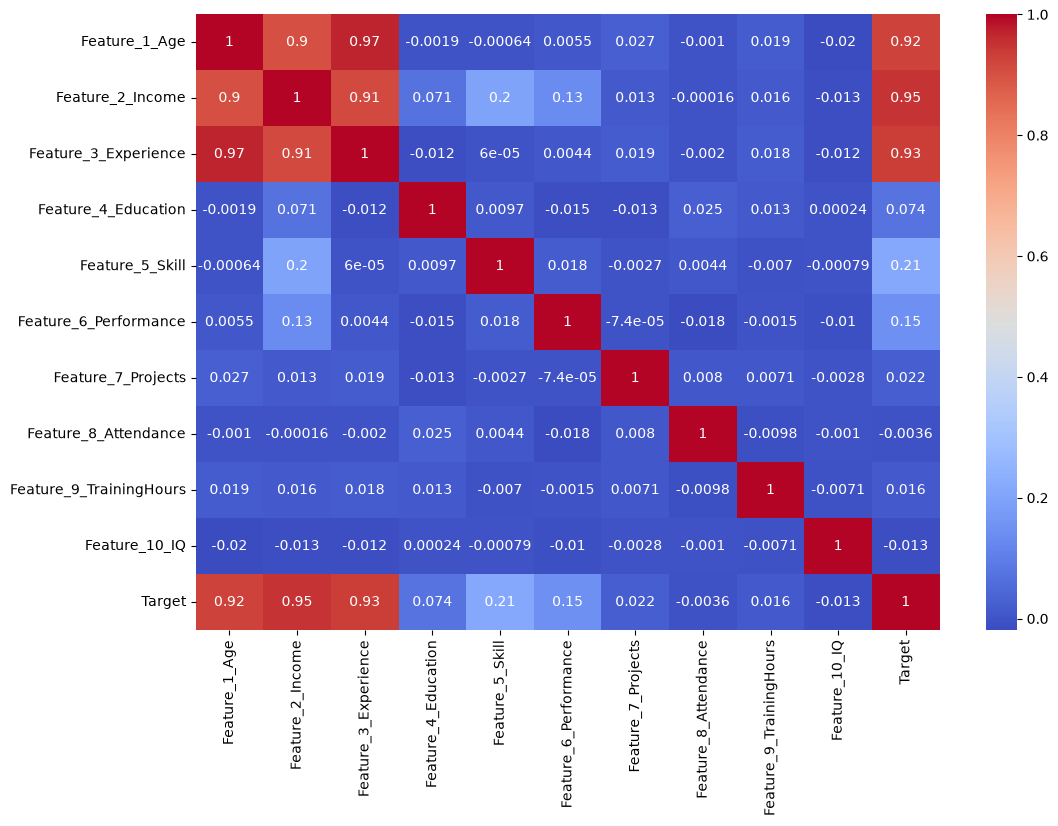

In [20]:
plt.figure(figsize=(12,8))

sns.heatmap(df.corr(),
            annot=True,
            cmap="coolwarm")

plt.show()

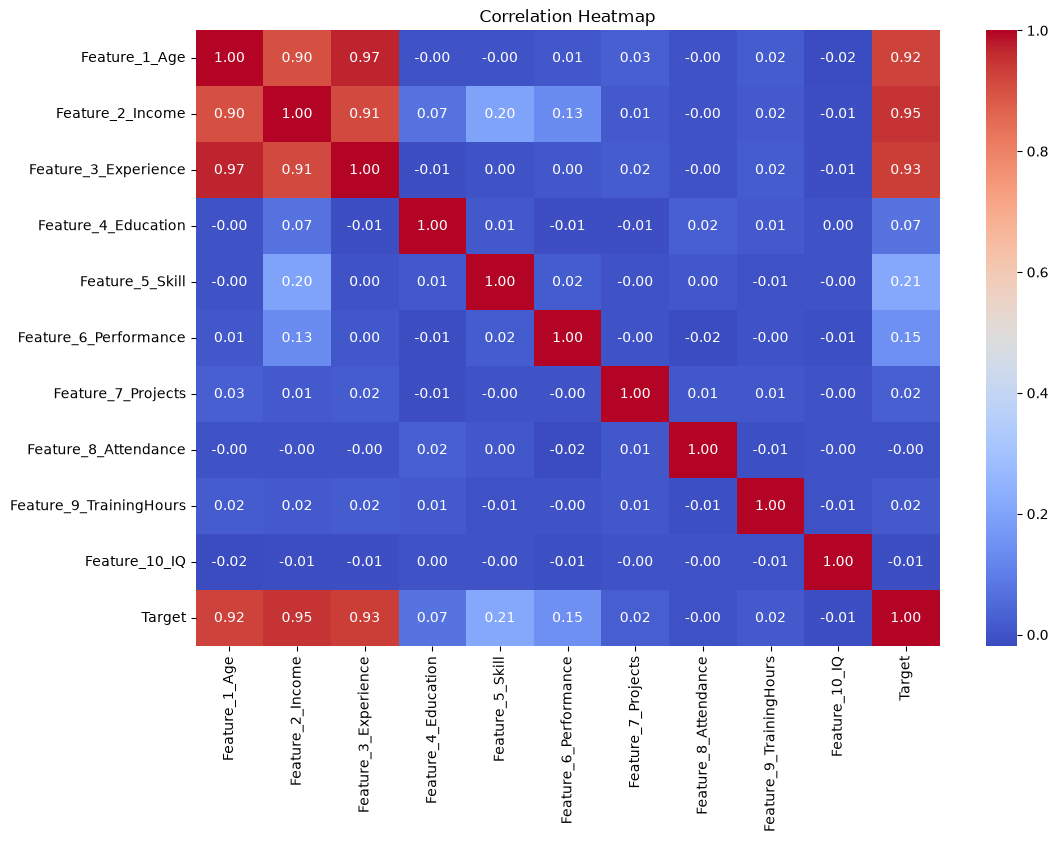

In [21]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

In [22]:
X = df.drop("Target", axis=1)
y = df["Target"]

In [23]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_standard = scaler.fit_transform(X)

pd.DataFrame(X_standard, columns=X.columns).head()

,Feature_1_Age,Feature_2_Income,Feature_3_Experience,Feature_4_Education,Feature_5_Skill,Feature_6_Performance,Feature_7_Projects,Feature_8_Attendance,Feature_9_TrainingHours,Feature_10_IQ
0,1.705297,1.823124,1.922798,-1.648075,0.974692,-0.551514,-0.458608,-0.520280,-1.139787,0.000291
1,1.194181,1.196622,1.406465,0.818734,-0.164419,-1.573986,-1.682821,-1.289142,-0.774079,-0.295887
2,1.023809,0.589341,0.890132,-1.648075,0.291225,-0.892338,1.290268,0.504869,-0.755794,1.086278
3,1.449739,1.486534,1.492520,-1.716598,1.031648,-1.028668,0.590718,0.077723,-0.481513,-0.789517
4,-0.594726,-1.011725,-0.572811,-1.305463,-1.417442,-0.074361,-1.158158,0.163152,-0.170661,-0.098435


In [24]:
from sklearn.preprocessing import MinMaxScaler

minmax = MinMaxScaler()

X_minmax = minmax.fit_transform(X)

pd.DataFrame(X_minmax, columns=X.columns).head()

,Feature_1_Age,Feature_2_Income,Feature_3_Experience,Feature_4_Education,Feature_5_Skill,Feature_6_Performance,Feature_7_Projects,Feature_8_Attendance,Feature_9_TrainingHours,Feature_10_IQ
0,1.000,0.746153,1.000,0.02,0.783333,0.34,0.368421,0.350,0.184211,0.500000
1,0.850,0.632214,0.850,0.74,0.450000,0.04,0.000000,0.125,0.289474,0.414286
2,0.800,0.521770,0.700,0.02,0.583333,0.24,0.894737,0.650,0.294737,0.814286
3,0.925,0.684939,0.875,0.00,0.800000,0.20,0.684211,0.525,0.373684,0.271429
4,0.325,0.230592,0.275,0.12,0.083333,0.48,0.157895,0.550,0.463158,0.471429


In [25]:
print("StandardScaler")

print(pd.DataFrame(X_standard, columns=X.columns).describe())

print("\n")

print("MinMaxScaler")

print(pd.DataFrame(X_minmax, columns=X.columns).describe())

StandardScaler
       Feature_1_Age  Feature_2_Income  Feature_3_Experience  \
count   1.000000e+04      1.000000e+04          1.000000e+04   
mean    2.586376e-16      1.136868e-16         -1.449507e-16   
std     1.000050e+00      1.000050e+00          1.000050e+00   
min    -1.702145e+00     -2.279653e+00         -1.519421e+00   
25%    -8.502846e-01     -8.317931e-01         -9.170329e-01   
50%     1.575942e-03     -1.567117e-02         -5.647821e-02   
75%     8.534365e-01      7.884929e-01          8.040765e-01   
max     1.705297e+00      3.218922e+00          1.922798e+00   

       Feature_4_Education  Feature_5_Skill  Feature_6_Performance  \
count         1.000000e+04     1.000000e+04           1.000000e+04   
mean          4.476419e-16     3.591794e-16          -3.367973e-16   
std           1.000050e+00     1.000050e+00           1.000050e+00   
min          -1.716598e+00    -1.702220e+00          -1.710316e+00   
25%          -8.943281e-01    -8.478865e-01          -8.24

In [26]:
df.corr()["Target"].sort_values(ascending=False)

Target                     1.000000
Feature_2_Income           0.951446
Feature_3_Experience       0.933965
Feature_1_Age              0.924999
Feature_5_Skill            0.211694
Feature_6_Performance      0.147334
Feature_4_Education        0.074225
Feature_7_Projects         0.022044
Feature_9_TrainingHours    0.015690
Feature_8_Attendance      -0.003641
Feature_10_IQ             -0.012648
Name: Target, dtype: float64

In [27]:
from sklearn.feature_selection import VarianceThreshold

X = df.drop("Target", axis=1)

selector = VarianceThreshold(threshold=0.1)

X_selected = selector.fit_transform(X)

selected_features = X.columns[selector.get_support()]

print("Selected Features:")
print(selected_features)

Selected Features:
Index(['Feature_1_Age', 'Feature_2_Income', 'Feature_3_Experience',
       'Feature_4_Education', 'Feature_5_Skill', 'Feature_6_Performance',
       'Feature_7_Projects', 'Feature_8_Attendance', 'Feature_9_TrainingHours',
       'Feature_10_IQ'],
      dtype='str')


In [28]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("Shape:", X_pca.shape)

Shape: (10000, 2)


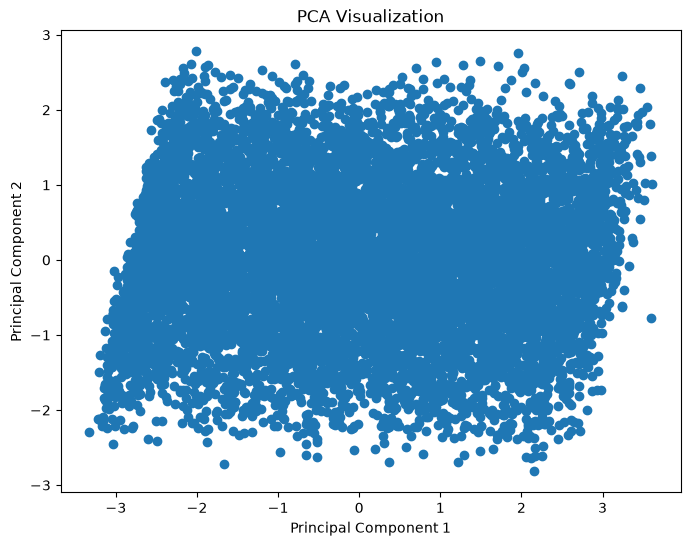

In [29]:
plt.figure(figsize=(8,6))

plt.scatter(X_pca[:,0], X_pca[:,1])

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Visualization")

plt.show()